In [1]:
import laspy
import numpy as np
import pandas as pd
import lasio
import matplotlib.pyplot as plt
import plotly.express as px


In [2]:
df = pd.read_excel("Formation Tops.xlsx")
df["Top depth [mMD_RKB]"] = df["Top depth [mMD_RKB]"].astype('float64')

In [3]:
df

,Well #,Formation,Top depth [mMD_RKB]
0,XX-X,FM-1,406.0
1,XX-X,FM-2,478.0
2,XX-X,FM-3,639.0
3,XX-X,FM-4,674.0
4,XX-X,FM-5,702.0
5,XX-X,FM-6,729.0
6,XX-X,FM-7,790.0
7,XX-X,FM-8,807.0
8,XX-X,FM-9,1168.0
9,XX-X,FM-10,1517.0


In [4]:
las = lasio.read("Well Log.LAS")

In [5]:
df_logs = las.df()
df_logs = df_logs.replace(-999.25, np.nan)
df_logs


,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,RDEP,RMED,RMIC,ROP,TH,U
DEPT,,,,,,,,,,,,,,,,
405.9936,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.1460,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.2984,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.4508,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
406.6032,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2209.6476,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.6901,NaN,NaN
2209.8000,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.7076,NaN,NaN
2209.9524,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.1661,NaN,NaN


In [6]:
# Nulls først (se punkt 3)
df_logs["Vp"] = (1e6 / df_logs["AC"]) * 0.3048      # m/s
df_logs["Vs"] = (1e6 / df_logs["ACS"]) * 0.3048     # m/s

df_logs["AI"] = df_logs["Vp"] * (df_logs["DEN"])  # (m/s)*(kg/m3)
df_logs["Vp/Vs"] = df_logs["Vp"] / df_logs["Vs"]


In [7]:
df_logs.columns

Index(['AC', 'ACS', 'BS', 'CALI', 'DEN', 'DENC', 'GR', 'K', 'NEU', 'PEF',
       'RDEP', 'RMED', 'RMIC', 'ROP', 'TH', 'U', 'Vp', 'Vs', 'AI', 'Vp/Vs'],
      dtype='object')

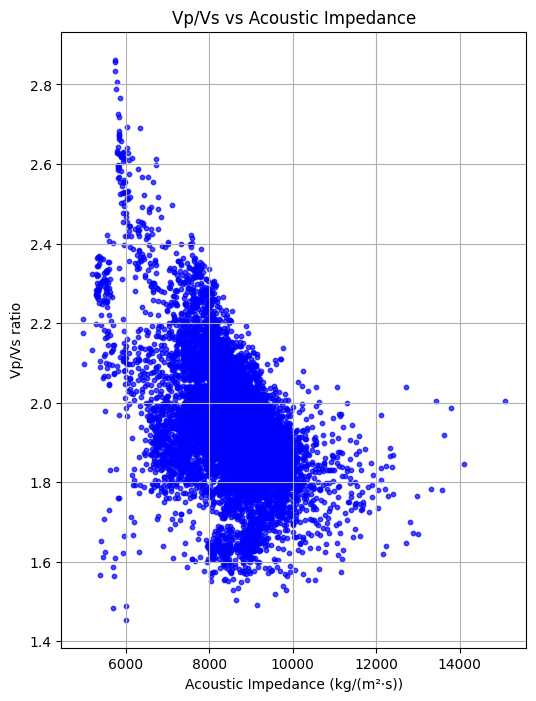

In [8]:
plt.figure(figsize=(6,8))
plt.scatter(df_logs["AI"], df_logs["Vp/Vs"], c='blue', s=10, alpha=0.7)
plt.xlabel("Acoustic Impedance (kg/(m²·s))")
plt.ylabel("Vp/Vs ratio")
plt.title("Vp/Vs vs Acoustic Impedance")
plt.grid(True)
plt.show()


In [9]:
df_logs_with_form = pd.merge_asof(
    df_logs.sort_values("DEPT"),
    df,
    left_on="DEPT",
    right_on="Top depth [mMD_RKB]",
    direction="backward"
)


In [10]:
df_logs_with_form

,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,...,ROP,TH,U,Vp,Vs,AI,Vp/Vs,Well #,Formation,Top depth [mMD_RKB]
0,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
2,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
3,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
4,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11835,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.6901,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11836,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.7076,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11837,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.1661,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11838,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.8002,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0


In [11]:
df_clean = df_logs_with_form.rename(columns={"Top depth [mMD_RKB]": "Depth"})


In [12]:
df_clean

,AC,ACS,BS,CALI,DEN,DENC,GR,K,NEU,PEF,...,ROP,TH,U,Vp,Vs,AI,Vp/Vs,Well #,Formation,Depth
0,NaN,NaN,26.0,NaN,NaN,NaN,78.5885,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,26.0,NaN,NaN,NaN,84.2673,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
2,NaN,NaN,26.0,NaN,NaN,NaN,83.9706,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
3,NaN,NaN,26.0,NaN,NaN,NaN,83.9938,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
4,NaN,NaN,26.0,NaN,NaN,NaN,76.8121,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-1,406.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11835,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,16.6901,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11836,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,15.7076,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11837,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,13.1661,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0
11838,NaN,NaN,8.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,12.8002,NaN,NaN,NaN,NaN,NaN,NaN,XX-X,FM-11,2141.0


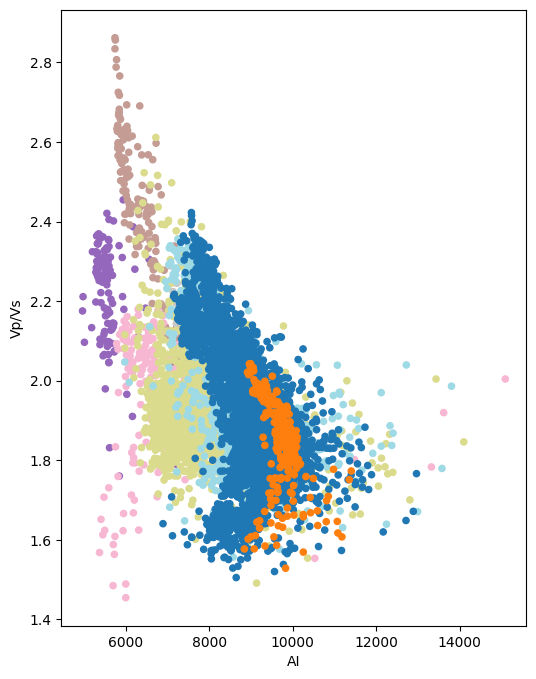

In [13]:
df_clean['Formation_code'] = pd.Categorical(df_clean['Formation']).codes

# Simple scatter
plt.figure(figsize=(6,8))
plt.scatter(df_clean['AI'], df_clean['Vp/Vs'], c=df_clean['Formation_code'], cmap='tab20', s=20)
plt.gca() # depth usually goes downward
plt.xlabel('AI')      # replace with your X-axis
plt.ylabel('Vp/Vs')
plt.show()


In [14]:
import plotly.express as px
import pandas as pd

# Add Formation_code to df_clean
df_clean['Formation_code'] = df_clean['Formation'].astype(str)

fig = px.scatter_3d(
    df_clean,
    x='AI',
    z='Depth',
    y='Vp/Vs',
    color='Formation_code',   # automatically colors by formation name
    size_max=5
)

fig.update_layout(scene=dict(zaxis=dict(autorange='reversed')))  # Depth goes downward
fig.show()

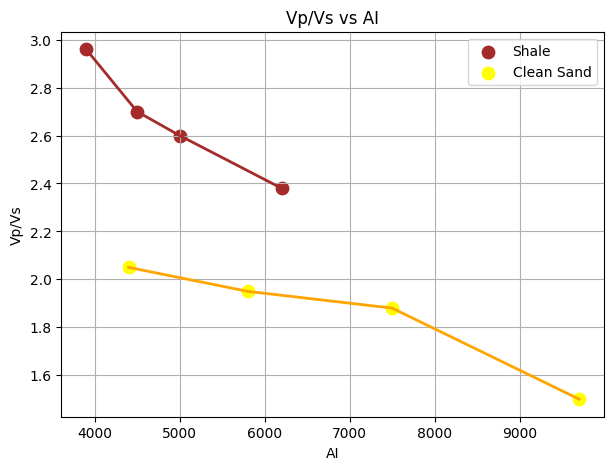

In [15]:
#Ca, egenlagd template basert på ødegaard sine empiriske data.
shale = [(3900, 2.96), (4500, 2.7), (5000, 2.6), (6200, 2.38)]

clean_sand = [(4400, 2.05), (5800, 1.95), (7500, 1.88), (9700, 1.5)]

shale_x, shale_y = zip(*shale)
sand_x, sand_y = zip(*clean_sand)

plt.figure(figsize=(7,5))
plt.scatter(shale_x, shale_y, color='brown', label='Shale', s=80)
plt.scatter(sand_x, sand_y, color='yellow', label='Clean Sand', s=80)
plt.plot(shale_x, shale_y, color='brown', linestyle='-', linewidth=2)
plt.plot(sand_x, sand_y, color='orange', linestyle='-', linewidth=2)
plt.xlabel('AI')
plt.ylabel('Vp/Vs')
plt.title('Vp/Vs vs AI')
plt.legend()
plt.grid(True)
plt.show()


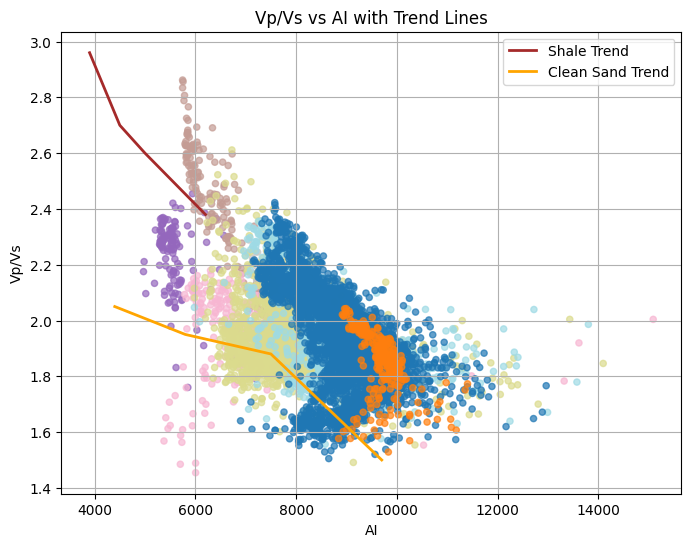

In [16]:
shale = [(3900, 2.96), (4500, 2.7), (5000, 2.6), (6200, 2.38)]
clean_sand = [(4400, 2.05), (5800, 1.95), (7500, 1.88), (9700, 1.5)]

shale_x, shale_y = zip(*shale)
sand_x, sand_y = zip(*clean_sand)

# Scatter from your dataframe
# Assuming df_clean has columns: 'AI', 'Vp/Vs', 'Formation'
df_clean['Formation_code'] = pd.Categorical(df_clean['Formation']).codes

plt.figure(figsize=(8,6))

# Scatter of actual data (colored by formation)
plt.scatter(df_clean['AI'], df_clean['Vp/Vs'], 
            c=df_clean['Formation_code'], cmap='tab20', s=20, alpha=0.7)

# Plot trend lines (shale and sand)
plt.plot(shale_x, shale_y, color='brown', linestyle='-', linewidth=2, label='Shale Trend')
plt.plot(sand_x, sand_y, color='orange', linestyle='-', linewidth=2, label='Clean Sand Trend')

plt.xlabel('AI')
plt.ylabel('Vp/Vs')
plt.title('Vp/Vs vs AI with Trend Lines')
plt.legend()
plt.grid(True)
plt.show()


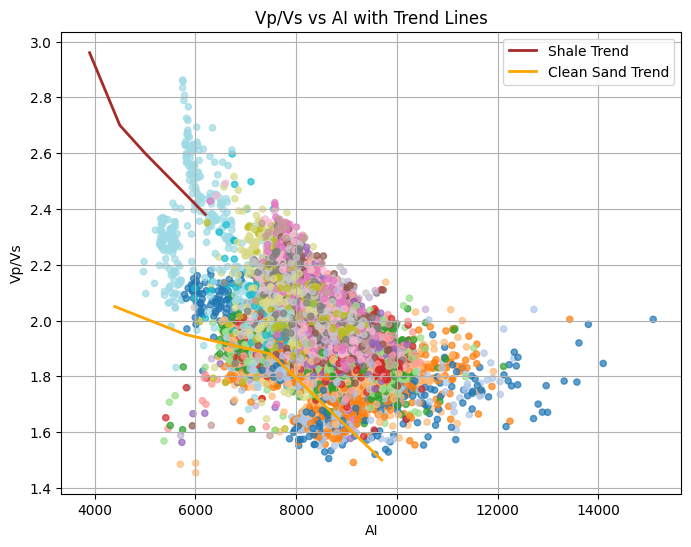

In [17]:
shale = [(3900, 2.96), (4500, 2.7), (5000, 2.6), (6200, 2.38)]
clean_sand = [(4400, 2.05), (5800, 1.95), (7500, 1.88), (9700, 1.5)]

shale_x, shale_y = zip(*shale)
sand_x, sand_y = zip(*clean_sand)

# Scatter from your dataframe
# Assuming df_clean has columns: 'AI', 'Vp/Vs', 'Formation'
df_clean['GR_color'] = pd.Categorical(df_clean['GR']).codes

plt.figure(figsize=(8,6))

# Scatter of actual data (colored by formation)
plt.scatter(df_clean['AI'], df_clean['Vp/Vs'], 
            c=df_clean['GR_color'], cmap='tab20', s=20, alpha=0.7)

# Plot trend lines (shale and sand)
plt.plot(shale_x, shale_y, color='brown', linestyle='-', linewidth=2, label='Shale Trend')
plt.plot(sand_x, sand_y, color='orange', linestyle='-', linewidth=2, label='Clean Sand Trend')

plt.xlabel('AI')
plt.ylabel('Vp/Vs')
plt.title('Vp/Vs vs AI with Trend Lines')
plt.legend()
plt.grid(True)
plt.show()
